# Imports & Dataset

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torchvision import datasets, models
from torch.utils.data import DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.metrics import classification_report, confusion_matrix

import numpy as np
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device ", device)

Using device  cuda


In [ ]:
# get the path to and download the CIFAKE dataset from kaggle, containing 60,000 real and 60,000 AI generated images using Stable Diffusion v4
path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")

print("Path to dataset files:", path)

In [ ]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

# Data Preprocessing

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [4]:
train_dataset = datasets.ImageFolder(
    root=f"{path}/train",
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=f"{path}/test",
    transform=test_transform
)

In [5]:
# train_dataset.classes
train_dataset[1]
print(train_dataset[0][0].shape)

torch.Size([3, 224, 224])


In [6]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Load Pretrained Model

In [7]:
# load EfficientNet architecture with pretrained weights on imagenet
model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

# Freeze early layers
for param in model.parameters():
    param.requires_grad = False

# check how many features replace only the final layer 
num_features = model.classifier[1].in_features
# add dropout and replace the final layer from num_features to 2 features (0 - real, 1 - fake)
model.classifier = nn.Sequential(
    nn.BatchNorm1d(num_features),
    nn.Dropout(0.3),
    nn.Linear(num_features, 2)
)

# train only the classifier
for param in model.classifier.parameters():
    param.requires_grad = True

# move the model to correct hardware
model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 148MB/s]


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr = 0.0001
)

# Model Training Function

In [9]:
def train(model, loader, optimizer, criterion):
    
    model.train()
    running_loss = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # forward pass, feed images through nn
        outputs = model(images)

        loss = criterion(outputs, labels)

        # reset gradient so they dont accumulate across batches
        optimizer.zero_grad()
        # gradient of the loss with respect to each weight
        loss.backward()
        # Adam optimizer updates the weight
        optimizer.step()

        # loss.item() converts the loss tensor into a Python number to calc avg loss later
        running_loss += loss.item()
    # return average loss per batch/epoch
    return running_loss / len(loader)

# Model Evaluation Function

In [10]:
def evaluate(model, loader):
    # switch the nn into evaluation mode i.e to disable dropout
    model.eval()

    # lists to store predicted labels and true labels
    all_preds = []
    all_labels = []

    # we are not training, so do not compute gradients
    with torch.no_grad():
        for images, labels in loader:

            # move images to the same hardware as model
            images = images.to(device)
            # forward pass, feed images through nn
            outputs = model(images)

            # find the highest value along a dimension
            _, preds = torch.max(outputs, 1)
            # move predictions back to CPU and save them in lists
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    # return true labels and predicted labels
    return all_labels, all_preds

# Training Loop

In [11]:
epochs = 20
for epoch in range(epochs):

    # unfreeze the last block starting from epoch 3 (finetuning the deeper layers)
    if epoch == 3:
        for param in model.features[-1].parameters():
            param.requires_grad = True

        optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-5
        )
    
    loss = train(model, train_loader, optimizer, criterion)

    labels, preds = evaluate(model, test_loader)

    accuracy = np.mean(np.array(labels) == np.array(preds))

    print(f"Epoch {epoch+1}/{epochs}")
    print("Loss:", loss)
    print("Accuracy:", accuracy)
    print()

Epoch 1/20
Loss: 0.40983574129104616
Accuracy: 0.84015

Epoch 2/20
Loss: 0.3640360869765282
Accuracy: 0.84455

Epoch 3/20
Loss: 0.3601820535826683
Accuracy: 0.8468

Epoch 4/20
Loss: 0.3503928108048439
Accuracy: 0.85825

Epoch 5/20
Loss: 0.33041970268011095
Accuracy: 0.86135

Epoch 6/20
Loss: 0.3169433930945396
Accuracy: 0.87155

Epoch 7/20
Loss: 0.30793986444473265
Accuracy: 0.8751

Epoch 8/20
Loss: 0.2992648123979568
Accuracy: 0.88825

Epoch 9/20
Loss: 0.29357802933692934
Accuracy: 0.883

Epoch 10/20
Loss: 0.2854910945534706
Accuracy: 0.89105

Epoch 11/20
Loss: 0.2822383004784584
Accuracy: 0.8925

Epoch 12/20
Loss: 0.275952635819912
Accuracy: 0.8933

Epoch 13/20
Loss: 0.27061991807937624
Accuracy: 0.89555

Epoch 14/20
Loss: 0.26859159596204757
Accuracy: 0.89395

Epoch 15/20
Loss: 0.2630410487174988
Accuracy: 0.89665

Epoch 16/20
Loss: 0.26086376302599906
Accuracy: 0.90225

Epoch 17/20
Loss: 0.2575108285617828
Accuracy: 0.8947

Epoch 18/20
Loss: 0.25348073439598084
Accuracy: 0.9099

Ep

# Model Metrics

In [12]:
labels, preds = evaluate(model, test_loader)
print(classification_report(labels, preds))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91     10000
           1       0.93      0.88      0.90     10000

    accuracy                           0.91     20000
   macro avg       0.91      0.91      0.91     20000
weighted avg       0.91      0.91      0.91     20000



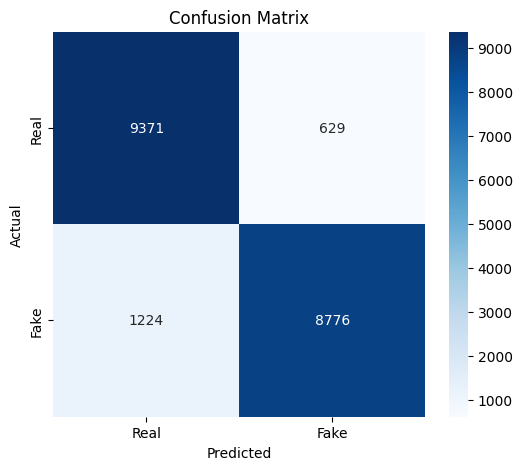

In [14]:
import seaborn as sns

# Plot the confusion matrix
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real","Fake"],
            yticklabels=["Real","Fake"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Save Model 

In [15]:
torch.save(model.state_dict(), "ai_image_detector.pth")